<a href="https://colab.research.google.com/github/mgt412/course_notebooks/blob/master/MGT412_Lecture_4_HighFrequencyData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FNCE 449 Day 2:  High-Frequency Finance. Trade and Quote Data.

## Working with dates and times

The relevant module for working natively with date-time objects is `datetime`.

There are seven fields in a **datetime** object :` year, month, day, hour, minute, second, microseconds`.

In [1]:
import datetime as dt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
d=dt.datetime.now()
d # current time

datetime.datetime(2026, 8, 17, 12, 31, 51, 540956)

In [2]:
d.year

2026

In [3]:
# individual date fields
d.year, d.month, d.day, d.hour, d.microsecond

(2026, 8, 17, 12, 540956)

In [4]:
# GMT time
dt.datetime.now(dt.timezone.utc)

datetime.datetime(2026, 8, 17, 18, 31, 51, 589235, tzinfo=datetime.timezone.utc)

We can use `timedelta` objects: subtracting two time objects creates a new type. $\Delta time$

How long did it take you to read this material?

In [5]:
d1=dt.datetime.now()
d1

datetime.datetime(2026, 8, 17, 12, 31, 51, 600858)

In [6]:
# Timedelta objects: difference between two times
d1=dt.datetime.now()
diff=d1-d
diff

datetime.timedelta(microseconds=70736)

## High-frequency trading data

We will work with high-frequency trading data from September 2023, as downloaded from `Databento`. 
Concretely, we will use several market data schemas for `ESZ3`, the E-Mini S&P 500 futures contract expiring on Dec 15, 2023. E-mini S&P 500 refers to an electronically-traded futures and options contract on the Chicago Mercantile Exchange (CME). Launched by the CME in 1997, the E-mini S&P 500 is open to all investors. It allows them to hedge their bets or speculate on the price movements of the S&P 500 index. The contract is cash-settled and is priced at $50 times the value of the S&P 500. 

### MBO Market Schema (Market by Order)

MBO describes an order-based data feed that provides the ability to view individual queue position, full depth of book and the size of individual orders at each price level.

In [7]:
# # First, create a historical client
# import databento as db
# import pandas as pd 

# client = db.Historical(key="db-RqnJGkKgqELRSkKeK8XAsHktsknGe")

# # Next, request ohlcv-1m bars for the time range we're interested in
# data = client.timeseries.get_range(
#     dataset="GLBX.MDP3",
#     schema="mbo",
#     symbols="ESZ3",
#     start=pd.Timestamp("2023-09-14T09:00", tz="US/Eastern"),
#     end=pd.Timestamp("2023-09-14T17:30", tz="US/Eastern"),
# )
# # Convert to dataframe with timestamps in the US/Eastern timezone
# df = data.to_df(tz="US/Eastern")
# len(df)

In [8]:
mbo=pd.read_csv("https://github.com/mariuszoican/fnce449/raw/main/Data/mbo_esz3.csv.gz",
                parse_dates=['ts_event','ts_recv']).set_index('ts_recv')

In [9]:
len(mbo)

6517395

Let's see how the data looks like:

In [10]:
mbo.head()

,ts_event,rtype,publisher_id,instrument_id,action,side,price,size,channel_id,order_id,flags,ts_in_delta,sequence,symbol
ts_recv,,,,,,,,,,,,,,
2023-09-14 09:00:00.061345896+00:00,2023-09-14 09:00:00.061237619+00:00,160,1,314863,C,A,4528.50,2,0,6412375152350,130,15881,38380078,ESZ3
2023-09-14 09:00:00.061370670+00:00,2023-09-14 09:00:00.061246373+00:00,160,1,314863,A,B,4528.25,1,0,6412375152362,130,13312,38380079,ESZ3
2023-09-14 09:00:00.061473344+00:00,2023-09-14 09:00:00.061370153+00:00,160,1,314863,M,B,4527.75,1,0,6412375040881,130,16173,38380081,ESZ3
2023-09-14 09:00:00.061479012+00:00,2023-09-14 09:00:00.061387729+00:00,160,1,314863,A,B,4528.25,3,0,6412375152363,130,13450,38380082,ESZ3
2023-09-14 09:00:00.061597613+00:00,2023-09-14 09:00:00.061512763+00:00,160,1,314863,C,A,4528.50,4,0,6412375152355,130,15230,38380083,ESZ3


In [11]:
mbo.columns.tolist() # check out the variables in the data

['ts_event',
 'rtype',
 'publisher_id',
 'instrument_id',
 'action',
 'side',
 'price',
 'size',
 'channel_id',
 'order_id',
 'flags',
 'ts_in_delta',
 'sequence',
 'symbol']

| MBO Field Name      | Description                                                                                                              |
|-----------------|--------------------------------------------------------------------------------------------------------------------------|
| `ts_recv`       | The capture-server-received timestamp expressed as the number of nanoseconds since the UNIX epoch.                       |
| `ts_event`      | The matching-engine-received timestamp expressed as the number of nanoseconds since the UNIX epoch.                      |
| `rtype`         | The record type. Each schema corresponds with a single rtype value.                                                      |
| `publisher_id`  | The publisher ID assigned by Databento, which denotes dataset and venue.                                                 |
| `instrument_id` | The numeric instrument ID.                                                                                               |
| `action`        | The event action. Can be [A]dd, [C]ancel, [M]odify, clea[R] book, [T]rade, or [F]ill.                                   |
| `side`          | The order side. Can be [A]sk, [B]id or [N]one.                                                                           |
| `price`         | The order price expressed as a signed integer where every 1 unit corresponds to 1e-9, i.e. 1/1,000,000,000 or 0.000000001.|
| `size`          | The order quantity.                                                                                                      |
| `channel_id`    | The channel ID assigned by Databento as an incrementing integer starting at zero.                                        |
| `order_id`      | The order ID assigned at the venue.                                                                                      |
| `flags`         | A combination of packet end with matching engine status.                                                                 |
| `ts_in_delta`   | The matching-engine-sending timestamp expressed as the number of nanoseconds before ts_recv.                             |
| `sequence`      | The message sequence number assigned at the venue.                                                                       |
| `symbol`        | The requested symbol for the instrument.                                                                                 |



In [12]:
len(mbo)

6517395

In [13]:
mbo.groupby('action').count() # check out the distribution of actions

,ts_event,rtype,publisher_id,instrument_id,side,price,size,channel_id,order_id,flags,ts_in_delta,sequence,symbol
action,,,,,,,,,,,,,
A,2590962,2590962,2590962,2590962,2590962,2590962,2590962,2590962,2590962,2590962,2590962,2590962,2590962
C,2586449,2586449,2586449,2586449,2586449,2586449,2586449,2586449,2586449,2586449,2586449,2586449,2586449
F,603569,603569,603569,603569,603569,603569,603569,603569,603569,603569,603569,603569,603569
M,480017,480017,480017,480017,480017,480017,480017,480017,480017,480017,480017,480017,480017
T,256398,256398,256398,256398,256398,256398,256398,256398,256398,256398,256398,256398,256398


In total, we have 6.52 million observations in this data set, out of which only 256 thousand are trades.   
**(Takeaway)**: Quote updates are much more frequent than trades on financial markets!

### How fast is the Databento feed?

In [14]:
# Checking timestamps
mbo['ts_event']

ts_recv
2023-09-14 09:00:00.061345896+00:00   2023-09-14 09:00:00.061237619+00:00
2023-09-14 09:00:00.061370670+00:00   2023-09-14 09:00:00.061246373+00:00
2023-09-14 09:00:00.061473344+00:00   2023-09-14 09:00:00.061370153+00:00
2023-09-14 09:00:00.061479012+00:00   2023-09-14 09:00:00.061387729+00:00
2023-09-14 09:00:00.061597613+00:00   2023-09-14 09:00:00.061512763+00:00
                                                      ...                
2023-09-14 16:59:59.918302126+00:00   2023-09-14 16:59:59.918200481+00:00
2023-09-14 16:59:59.965989382+00:00   2023-09-14 16:59:59.965896849+00:00
2023-09-14 16:59:59.972612091+00:00   2023-09-14 16:59:59.972518539+00:00
2023-09-14 16:59:59.997967810+00:00   2023-09-14 16:59:59.997868993+00:00
2023-09-14 16:59:59.999551577+00:00   2023-09-14 16:59:59.999456123+00:00
Name: ts_event, Length: 6517395, dtype: datetime64[ns, UTC]

In [15]:
# let us extract the microsecond from each timestamp
mbo['ts_event'].apply(lambda x: x.microsecond)

ts_recv
2023-09-14 09:00:00.061345896+00:00     61237
2023-09-14 09:00:00.061370670+00:00     61246
2023-09-14 09:00:00.061473344+00:00     61370
2023-09-14 09:00:00.061479012+00:00     61387
2023-09-14 09:00:00.061597613+00:00     61512
                                        ...  
2023-09-14 16:59:59.918302126+00:00    918200
2023-09-14 16:59:59.965989382+00:00    965896
2023-09-14 16:59:59.972612091+00:00    972518
2023-09-14 16:59:59.997967810+00:00    997868
2023-09-14 16:59:59.999551577+00:00    999456
Name: ts_event, Length: 6517395, dtype: int64

What is the latency of orders on Chicago mercantile exchange?

In [16]:
mbo=mbo.reset_index() # reset the index
mbo['ts_recv']-mbo['ts_event']

0         0 days 00:00:00.000108277
1         0 days 00:00:00.000124297
2         0 days 00:00:00.000103191
3         0 days 00:00:00.000091283
4         0 days 00:00:00.000084850
                     ...           
6517390   0 days 00:00:00.000101645
6517391   0 days 00:00:00.000092533
6517392   0 days 00:00:00.000093552
6517393   0 days 00:00:00.000098817
6517394   0 days 00:00:00.000095454
Length: 6517395, dtype: timedelta64[ns]

In [17]:
(mbo['ts_recv']-mbo['ts_event']).mean()

Timedelta('0 days 00:00:00.000224724')

   Let us study order cancellations.
1. How many orders are cancelled?
2. How long does it take before an order is cancelled?

In [18]:
mbo_add=mbo[mbo['action']=='A'][['ts_event','order_id']] # extract only the new orders
mbo_cancel=mbo[mbo['action']=='C'][['ts_event','order_id']] # extract when the order is removed from book

mbo_add=mbo_add.rename(columns={'ts_event':'ts_add'}) # rename the columns
mbo_cancel=mbo_cancel.rename(columns={'ts_event':'ts_cancel'}) # rename the columns

In [19]:
mbo_cancel

,ts_cancel,order_id
0,2023-09-14 09:00:00.061237619+00:00,6412375152350
4,2023-09-14 09:00:00.061512763+00:00,6412375152355
5,2023-09-14 09:00:00.061606175+00:00,6412375152351
8,2023-09-14 09:00:00.096959185+00:00,6412375151191
9,2023-09-14 09:00:00.096964783+00:00,6412375151275
...,...,...
6517376,2023-09-14 16:59:59.522509683+00:00,6412380039900
6517380,2023-09-14 16:59:59.538865661+00:00,6412380039747
6517383,2023-09-14 16:59:59.651151653+00:00,6412380039872
6517385,2023-09-14 16:59:59.834433819+00:00,6412380039320


In [20]:
mbo_pivot=pd.merge(mbo_add,mbo_cancel,how='left',on='order_id') # merge the two dataframes
mbo_pivot['delay']=mbo_pivot['ts_cancel']-mbo_pivot['ts_add'] # calculate the delay
mbo_pivot.head()

,ts_add,order_id,ts_cancel,delay
0,2023-09-14 09:00:00.061246373+00:00,6412375152362,2023-09-14 09:00:00.097101537+00:00,0 days 00:00:00.035855164
1,2023-09-14 09:00:00.061387729+00:00,6412375152363,2023-09-14 09:00:00.504344405+00:00,0 days 00:00:00.442956676
2,2023-09-14 09:00:00.104123991+00:00,6412375152368,2023-09-14 09:00:00.120996221+00:00,0 days 00:00:00.016872230
3,2023-09-14 09:00:00.114815347+00:00,6412375152369,2023-09-14 09:00:00.922031713+00:00,0 days 00:00:00.807216366
4,2023-09-14 09:00:00.114945103+00:00,6412375152370,2023-09-14 09:00:00.504462271+00:00,0 days 00:00:00.389517168


In [21]:
mbo_pivot.count()

ts_add       2590962
order_id     2590962
ts_cancel    2580802
delay        2580802
dtype: int64

In [22]:
# Count the number of non-cancelled orders
(mbo_pivot.count()['ts_add']-mbo_pivot.count()['ts_cancel'], 
100*(mbo_pivot.count()['ts_add']-mbo_pivot.count()['ts_cancel'])/mbo_pivot.count()['ts_add'])

(np.int64(10160), np.float64(0.39213234312197554))

In [23]:
mbo_pivot['delay'].describe() # summary statistics

count                      2580802
mean     0 days 00:00:40.692982066
std      0 days 00:06:29.987787130
min      0 days 00:00:00.000000176
25%      0 days 00:00:00.007478825
50%      0 days 00:00:00.107520039
75%      0 days 00:00:01.035407066
max      0 days 07:11:20.407575056
Name: delay, dtype: object

## Data visualization in *matplotlib* and *seaborn*

Useful functions and methods

1. **Plot function**: `plt.plot(x,y, options)`
2. **Add a grid**: `plt.grid()`
3. **Custom axis limits**: `plt.xlim(xmin, xmax)`
4. "**Tight" axes:** `plt.axis(’tight’)`
5. **Axes labels**: `plt.xlabel(), plt.ylabel()`
6. **Add a title**: `plt.title()`
7. **Show the plot**: `plt.show()`
8. **Save the plot**: `plt.save(path)`

| Plot option   | Python syntax |   
|-------|----------|
| Color | c= or color= | 
|  Line width | lw= or linewidth= |
| Line style | ls= or linestyle=| 


Colors and styles:

| Color | Styles |
|-------|----------|
**b** blue | **-** solid |
**g** green | **--** dashed |
**r** red | ** -.** dash-dot |
**k** black | **:** dotted |
**c** cyan | **.** point marker |
**m** magenta | **o $< >$ +** other markers |


We import the `matplotlib` and `seaborn` libraries for data visualization.

In [24]:
import matplotlib.pyplot as plt # most standard plotting library
import seaborn as sns # a modern plotting library
import matplotlib.gridspec as gridspec # helps with plotting multiple figures
from matplotlib.dates import DateFormatter
import numpy as np

In [25]:
mbo_pivot['second_threshold']=1*(mbo_pivot.delay>dt.timedelta(seconds=1)) 
# create a dummy variable for delays greater than 1 second
mbo_pivot['delay_seconds']=mbo_pivot['delay'].apply(lambda x: x.total_seconds()) # convert the delay to seconds
mbo_pivot.groupby('second_threshold').count() # check the distribution of the dummy variable

,ts_add,order_id,ts_cancel,delay,delay_seconds
second_threshold,,,,,
0,1916973,1916973,1906813,1906813,1906813
1,673989,673989,673989,673989,673989


In [26]:
mbo_pivot

,ts_add,order_id,ts_cancel,delay,second_threshold,delay_seconds
0,2023-09-14 09:00:00.061246373+00:00,6412375152362,2023-09-14 09:00:00.097101537+00:00,0 days 00:00:00.035855164,0,0.035855
1,2023-09-14 09:00:00.061387729+00:00,6412375152363,2023-09-14 09:00:00.504344405+00:00,0 days 00:00:00.442956676,0,0.442956
2,2023-09-14 09:00:00.104123991+00:00,6412375152368,2023-09-14 09:00:00.120996221+00:00,0 days 00:00:00.016872230,0,0.016872
3,2023-09-14 09:00:00.114815347+00:00,6412375152369,2023-09-14 09:00:00.922031713+00:00,0 days 00:00:00.807216366,0,0.807216
4,2023-09-14 09:00:00.114945103+00:00,6412375152370,2023-09-14 09:00:00.504462271+00:00,0 days 00:00:00.389517168,0,0.389517
...,...,...,...,...,...,...
2590957,2023-09-14 16:59:59.866029415+00:00,6412380039911,NaT,NaT,0,NaN
2590958,2023-09-14 16:59:59.918200481+00:00,6412380039912,NaT,NaT,0,NaN
2590959,2023-09-14 16:59:59.972518539+00:00,6412380039913,NaT,NaT,0,NaN
2590960,2023-09-14 16:59:59.997868993+00:00,6412380039914,NaT,NaT,0,NaN


<Axes: xlabel='delay_seconds', ylabel='Percent'>

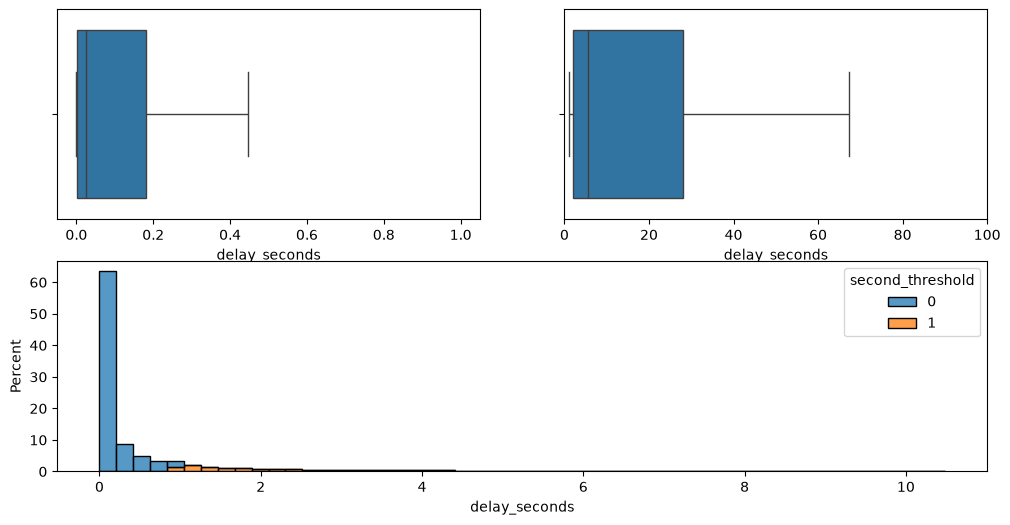

In [27]:
gs=gridspec.GridSpec(2,2)
fig=plt.figure(figsize=(12,6),facecolor='white') # generate a figure of given size

ax=fig.add_subplot(gs[0,0])
sns.boxplot(data=mbo_pivot[mbo_pivot.second_threshold==0], x='delay_seconds', fliersize=0) # boxplot of the delay

ax=fig.add_subplot(gs[0,1])
sns.boxplot(data=mbo_pivot[mbo_pivot.second_threshold==1], x='delay_seconds', fliersize=0) # boxplot of the delay
plt.xlim(0,100)

ax=fig.add_subplot(gs[1,:])
sns.histplot(data=mbo_pivot[mbo_pivot['delay_seconds']<mbo_pivot['delay_seconds'].quantile(0.9)], 
            x='delay_seconds',hue='second_threshold',common_norm=True,
             stat='percent',multiple='stack',bins=50)

### Tracking an order

In [28]:
def penultimate(series):
    if len(series) > 1:
        return series.iloc[-2]
    else:
        return series.iloc[0]

order_lives=mbo.groupby('order_id').agg({'size': 'count','action':['first','last',penultimate]})
#order_lives.columns=['update_count','first_entry','last_entry','penultimate_entry']
order_lives.head()

size action                 
              count  first last penultimate
order_id                                   
6412326632899     4      M    C           F
6412332983125     9      M    C           F
6412333729711     7      M    C           F
6412333904779    21      M    C           F
6412334215200     2      M    C           M

In [29]:
order_lives.columns=['update_count','first_entry','last_entry','penultimate_entry']
order_lives.head()

,update_count,first_entry,last_entry,penultimate_entry
order_id,,,,
6412326632899,4,M,C,F
6412332983125,9,M,C,F
6412333729711,7,M,C,F
6412333904779,21,M,C,F
6412334215200,2,M,C,M


In [30]:
order_lives[order_lives.first_entry=='A'].groupby(['penultimate_entry','last_entry']).count()

update_count  first_entry
penultimate_entry last_entry                           
A                 A                   8216         8216
                  C                2023186      2023186
                  M                    641          641
C                 T                      2            2
F                 C                 501675       501675
                  M                     21           21
M                 C                  45849        45849
                  M                   1281         1281

In [31]:
order_lives[(order_lives.first_entry=='A') & ((order_lives.penultimate_entry=='F'))].sort_values(
    by='update_count',ascending=False)

,update_count,first_entry,last_entry,penultimate_entry
order_id,,,,
6412378184741,4424,A,C,F
6412376633589,3877,A,C,F
6412378378625,2094,A,C,F
6412377936031,2009,A,C,F
6412376518038,1864,A,C,F
...,...,...,...,...
6412377074196,3,A,C,F
6412377074195,3,A,C,F
6412377074194,3,A,C,F


In [32]:
mbo[mbo.order_id==6412378184741]

,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,price,size,channel_id,order_id,flags,ts_in_delta,sequence,symbol
3975312,2023-09-14 14:21:11.592826825+00:00,2023-09-14 14:21:11.592731277+00:00,160,1,314863,A,A,4530.50,1,0,6412378184741,130,17458,43546636,ESZ3
3975873,2023-09-14 14:21:12.650844887+00:00,2023-09-14 14:21:12.650757323+00:00,160,1,314863,M,A,4530.75,1,0,6412378184741,130,13715,43547466,ESZ3
3976089,2023-09-14 14:21:13.023305349+00:00,2023-09-14 14:21:13.023214479+00:00,160,1,314863,M,A,4531.00,1,0,6412378184741,130,13363,43547767,ESZ3
3977086,2023-09-14 14:21:14.546273493+00:00,2023-09-14 14:21:14.546185853+00:00,160,1,314863,M,A,4530.75,1,0,6412378184741,130,13956,43549186,ESZ3
3977394,2023-09-14 14:21:14.652705726+00:00,2023-09-14 14:21:14.652600843+00:00,160,1,314863,M,A,4530.50,1,0,6412378184741,130,14800,43549446,ESZ3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5519617,2023-09-14 15:42:16.917256571+00:00,2023-09-14 15:42:16.917165483+00:00,160,1,314863,M,A,4542.25,1,0,6412378184741,130,15320,45414979,ESZ3
5520466,2023-09-14 15:42:17.770056571+00:00,2023-09-14 15:42:17.769968479+00:00,160,1,314863,M,A,4542.00,1,0,6412378184741,130,15534,45415759,ESZ3
5521064,2023-09-14 15:42:18.083260729+00:00,2023-09-14 15:42:18.083172859+00:00,160,1,314863,M,A,4541.75,1,0,6412378184741,130,13430,45416200,ESZ3
5521421,2023-09-14 15:42:18.454181693+00:00,2023-09-14 15:42:18.453776565+00:00,160,1,314863,F,A,4541.75,1,0,6412378184741,0,16307,45416704,ESZ3


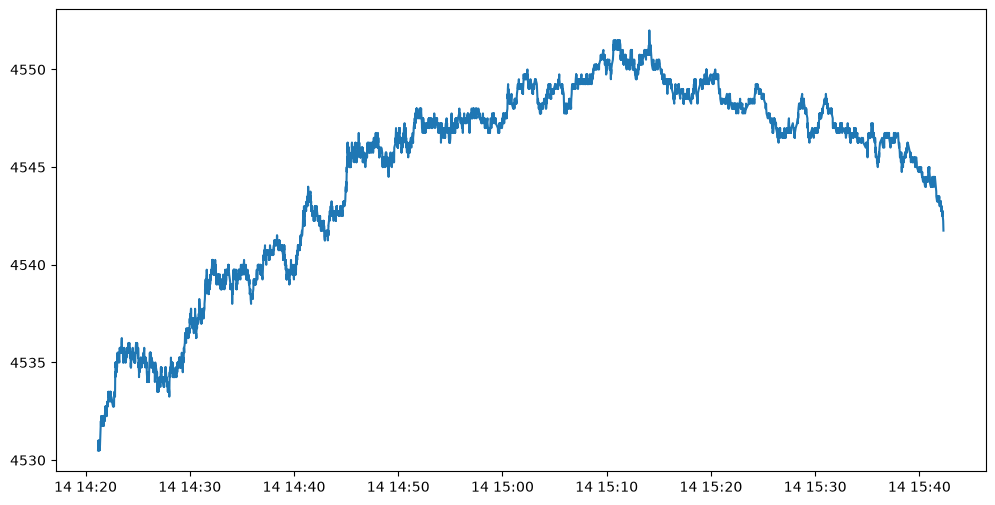

In [33]:
fig=plt.figure(figsize=(12,6),facecolor='white') # generate a figure of given size
plt.plot(mbo[mbo.order_id==6412378184741]['ts_event'].to_numpy(), mbo[mbo.order_id==6412378184741]['price'].to_numpy())

In [34]:
mbo[mbo.order_id==6412378184741]['ts_event'].diff().median()

Timedelta('0 days 00:00:00.548492498')

### More plots
Plot the trade prices time series.
Label the axes and give the figure an appropriate title.

Text(0.5, 1.0, 'E-Mini Transaction Prices')

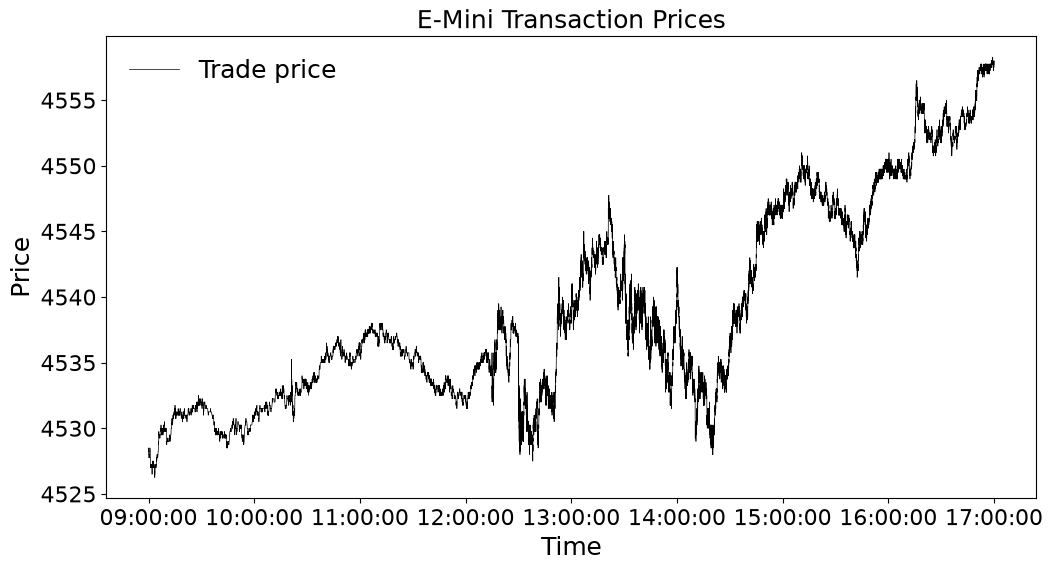

In [35]:
trades=mbo[mbo['action']=='T'] # extract only the trades

gs=gridspec.GridSpec(1,1)
fig=plt.figure(figsize=(12,6),facecolor='white') # generate a figure of given size

ax=fig.add_subplot(gs[0,0])

plt.plot(trades['ts_event'].to_numpy(),trades['price'].to_numpy(),
         color='black',linewidth=0.5,label='Trade price') # plot the price
plt.xlabel("Time", fontsize=18) # create an x-label with given font
plt.ylabel("Price", fontsize=18) # create an y-label with given font

# Define the date format
date_form = DateFormatter("%H:%M:%S")
ax.xaxis.set_major_formatter(date_form)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

plt.legend(loc='best',fontsize=18, frameon=False)

plt.title("E-Mini Transaction Prices", fontsize=18) # create figure title

### Figures in pyplot
A figure contains one or more plotted series. We define the figure size as follows:  
`plt.figure (figsize =(7 ,4)) # add figure size`

**Legend**  
`plt.legend (loc=’best’, fontsize =18)`

Legend location(loc) can take multiple values: `’best’, ’upper right’, ’center left’, ’lower right’, ’center’.`..

Plotted series **labels** given by option `label=`.

## MBP Market Schema (Market by price)
This schema provides changes to and snapshots of aggregated book depth, keyed by price. This is limited to a fixed number of levels from the top. We denote number of levels displayed in the schema with a suffix, such as `mbp-1` and `mbp-10`.

In [36]:
mbp=pd.read_csv("https://github.com/mariuszoican/fnce449/raw/main/Data/mb1_esz3.csv.gz",
                parse_dates=['ts_event','ts_recv']).set_index('ts_recv')

In [37]:
mbp['bid_sz_00']=mbp['bid_sz_00'].map(float)
mbp['ask_sz_00']=mbp['ask_sz_00'].map(float)
mbp.head()

,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,flags,ts_in_delta,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00,symbol
ts_recv,,,,,,,,,,,,,,,,,,,
2023-09-14 14:00:00.000484184+00:00,2023-09-14 14:00:00.000080935+00:00,1,1,314863,C,B,0,4540.25,1,130,16224,42640246,4540.25,4540.5,67.0,35.0,29,25,ESZ3
2023-09-14 14:00:00.000562779+00:00,2023-09-14 14:00:00.000473749+00:00,1,1,314863,C,A,0,4540.50,1,130,13427,42640248,4540.25,4540.5,67.0,34.0,29,24,ESZ3
2023-09-14 14:00:00.000606502+00:00,2023-09-14 14:00:00.000487739+00:00,1,1,314863,A,A,0,4540.50,2,130,13627,42640252,4540.25,4540.5,67.0,36.0,29,25,ESZ3
2023-09-14 14:00:00.000676414+00:00,2023-09-14 14:00:00.000567539+00:00,1,1,314863,C,A,0,4540.50,1,130,12653,42640256,4540.25,4540.5,67.0,35.0,29,24,ESZ3
2023-09-14 14:00:00.000782624+00:00,2023-09-14 14:00:00.000695473+00:00,1,1,314863,C,A,0,4540.50,2,130,14276,42640263,4540.25,4540.5,67.0,33.0,29,23,ESZ3


| Field Name   | Type      | Description                                                                                                              |
|--------------|-----------|--------------------------------------------------------------------------------------------------------------------------|
| `publisher_id` | `uint16_t` | The publisher ID assigned by Databento, which denotes the dataset and venue.                                              |
| `instrument_id` | `uint32_t` | The numeric instrument ID.                                                                                                |
| `ts_event`   | `uint64_t` | The matching-engine-received timestamp expressed as the number of nanoseconds since the UNIX epoch.                       |
| `price`      | `int64_t`  | The order price where every 1 unit corresponds to 1e-9, i.e. 1/1,000,000,000 or 0.000000001.                             |
| `size`       | `uint32_t` | The order quantity.                                                                                                      |
| `action`     | `char`     | The event action. Can be Add, Cancel, Modify, cleaR book, or Trade.                                                      |
| `side`       | `char`     | The order side. Can be Ask, Bid, or None.                                                                                |
| `flags`      | `uint8_t`  | A combination of packet end with matching engine status.                                                                 |
| `depth`      | `uint8_t`  | The book level where the update event occurred.                                                                          |
| `ts_recv`    | `uint64_t` | The capture-server-received timestamp expressed as the number of nanoseconds since the UNIX epoch.                       |
| `ts_in_delta`| `int32_t`  | The matching-engine-sending timestamp expressed as the number of nanoseconds before ts_recv.                             |
| `sequence`   | `uint32_t` | The message sequence number assigned at the venue.                                                                       |
| `bid_px_N`   | `int64_t`  | The bid price at level N (top level if N = 00).                                                                          |
| `ask_px_N`   | `int64_t`  | The ask price at level N (top level if N = 00).                                                                          |
| `bid_sz_N`   | `uint32_t` | The bid size at level N (top level if N = 00).                                                                           |
| `ask_sz_N`   | `uint32_t` | The ask size at level N (top level if N = 00).                                                                           |
| `bid_ct_N`   | `uint32_t` | The number of bid orders at level N (top level if N = 00).                                                               |
| `ask_ct_N`   | `uint32_t` | The number of ask orders at level N (top level if N = 00).                                                               |


### Task: Legends and multiple plots

1. Plot the bid and ask quotes time series for July 1, 2009.
2. Create an appropriate legend in the lower right corner.
3. Label the axes and give the figure an appropriate title.

Text(0, 0.5, 'Bid/ask price')

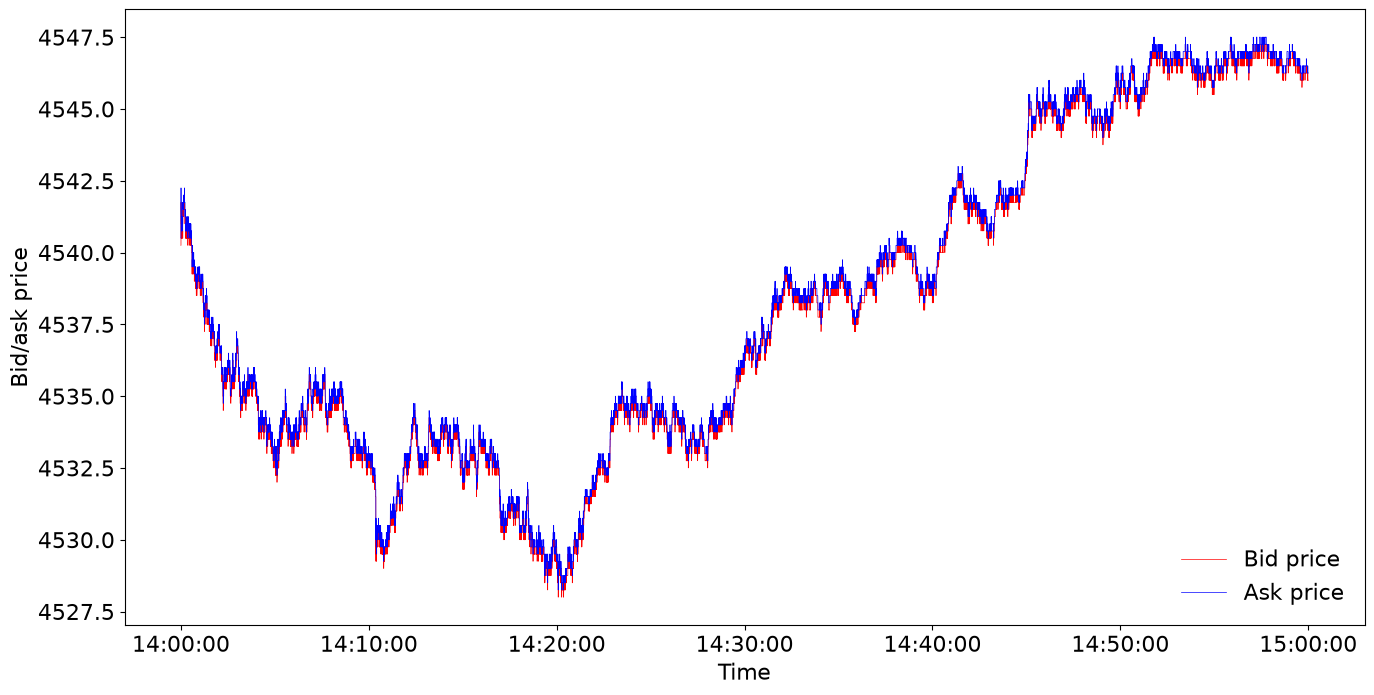

In [38]:
gs=gridspec.GridSpec(1,1)
fig=plt.figure(figsize=(16,8),facecolor='white') # generate a figure of given size

ax=fig.add_subplot(gs[0,0])

plt.plot(mbp['ts_event'].to_numpy(),mbp['bid_px_00'].to_numpy(),
         color='r',label='Bid price',linewidth=0.5) # plot the bid price
plt.plot(mbp['ts_event'].to_numpy(),mbp['ask_px_00'].to_numpy(),
         color='b',label='Ask price',linewidth=0.5) # plot the ask price

date_form = DateFormatter("%H:%M:%S")
ax.xaxis.set_major_formatter(date_form)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

plt.legend(loc='lower right', fontsize=16, frameon=False)
plt.xlabel("Time", fontsize=16)

plt.ylabel("Bid/ask price", fontsize=16)

### Re-sample the series

In [40]:
mbp

,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,flags,ts_in_delta,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00,symbol
ts_recv,,,,,,,,,,,,,,,,,,,
2023-09-14 14:00:00.000484184+00:00,2023-09-14 14:00:00.000080935+00:00,1,1,314863,C,B,0,4540.25,1,130,16224,42640246,4540.25,4540.50,67.0,35.0,29,25,ESZ3
2023-09-14 14:00:00.000562779+00:00,2023-09-14 14:00:00.000473749+00:00,1,1,314863,C,A,0,4540.50,1,130,13427,42640248,4540.25,4540.50,67.0,34.0,29,24,ESZ3
2023-09-14 14:00:00.000606502+00:00,2023-09-14 14:00:00.000487739+00:00,1,1,314863,A,A,0,4540.50,2,130,13627,42640252,4540.25,4540.50,67.0,36.0,29,25,ESZ3
2023-09-14 14:00:00.000676414+00:00,2023-09-14 14:00:00.000567539+00:00,1,1,314863,C,A,0,4540.50,1,130,12653,42640256,4540.25,4540.50,67.0,35.0,29,24,ESZ3
2023-09-14 14:00:00.000782624+00:00,2023-09-14 14:00:00.000695473+00:00,1,1,314863,C,A,0,4540.50,2,130,14276,42640263,4540.25,4540.50,67.0,33.0,29,23,ESZ3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-14 14:59:59.954906864+00:00,2023-09-14 14:59:59.954802705+00:00,1,1,314863,A,B,0,4546.00,4,130,16122,44648689,4546.00,4546.25,84.0,98.0,43,38,ESZ3
2023-09-14 14:59:59.955000480+00:00,2023-09-14 14:59:59.954916265+00:00,1,1,314863,C,A,0,4546.25,4,130,15476,44648690,4546.00,4546.25,84.0,94.0,43,37,ESZ3
2023-09-14 14:59:59.957158611+00:00,2023-09-14 14:59:59.957063705+00:00,1,1,314863,A,B,0,4546.00,1,130,15590,44648692,4546.00,4546.25,85.0,94.0,44,37,ESZ3


In [41]:
# keep the last bid/ask snapshot every minute 
mbp_1t=mbp.resample('1min')[['bid_px_00','ask_px_00','bid_sz_00','ask_sz_00']].last()
mbp_1t.head(20)

,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00
ts_recv,,,,
2023-09-14 14:00:00+00:00,4539.00,4539.25,54.0,42.0
2023-09-14 14:01:00+00:00,4536.75,4537.00,54.0,46.0
2023-09-14 14:02:00+00:00,4536.50,4536.75,52.0,62.0
2023-09-14 14:03:00+00:00,4535.25,4535.50,5.0,65.0
2023-09-14 14:04:00+00:00,4533.00,4533.25,50.0,70.0
2023-09-14 14:05:00+00:00,4533.50,4533.75,60.0,3.0
2023-09-14 14:06:00+00:00,4534.50,4534.75,38.0,69.0
2023-09-14 14:07:00+00:00,4534.50,4534.75,46.0,50.0
2023-09-14 14:08:00+00:00,4533.00,4533.25,124.0,78.0


In [42]:
len(mbp), len(mbp_1t)

(1043871, 60)

### Two-axes plot

Let us plot both (1) spreads and (2) transaction prices for E-mini futures.   
Of course, they have different scales.  
We need to duplicate the y-axis, while keeping the x-axis the same `(twinx)`.

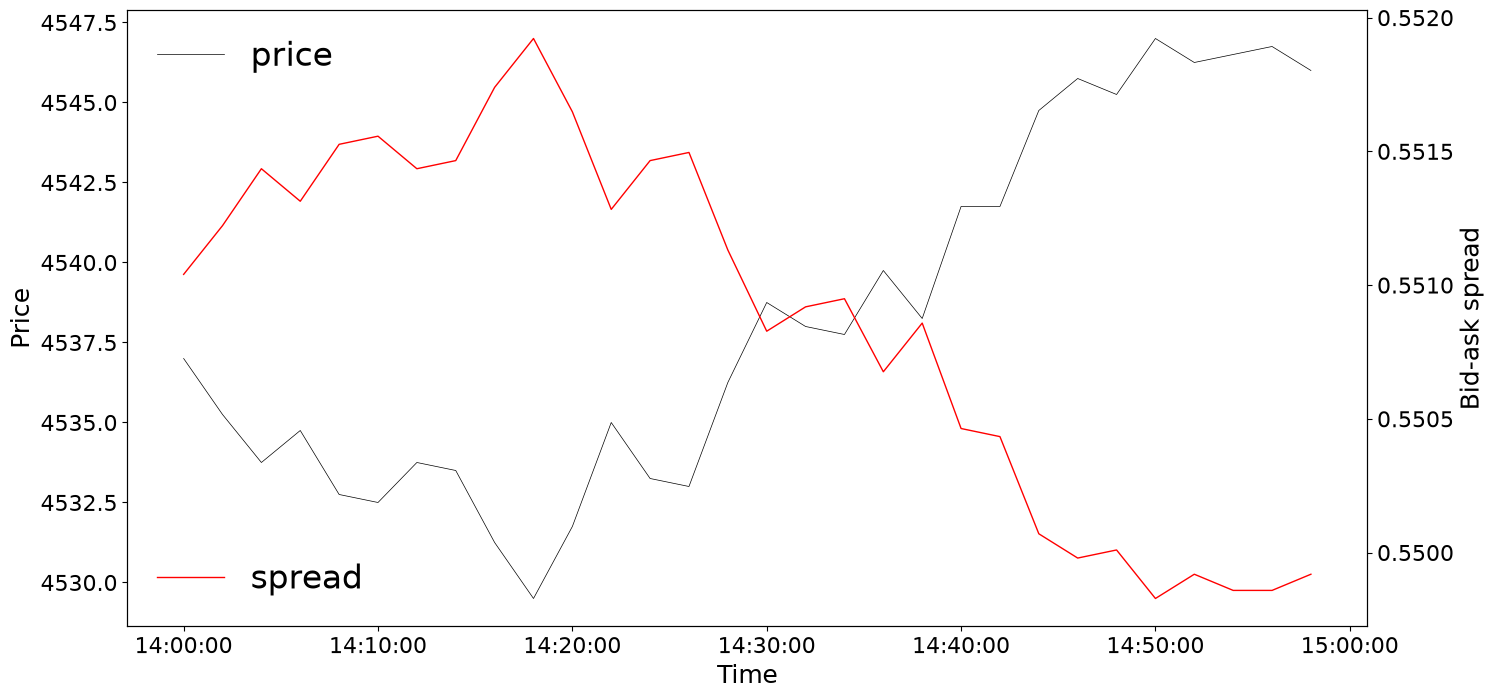

In [44]:
mbp['spread']=10000*(mbp['ask_px_00']-mbp['bid_px_00'])/((mbp['ask_px_00']+mbp['bid_px_00'])/2)


# how to resample the data
mbp_rs=mbp.resample('2min',on='ts_event').last().reset_index()


gs=gridspec.GridSpec(1,1)
fig=plt.figure(figsize=(16,8),facecolor='white') # generate a figure of given size

ax1=fig.add_subplot(gs[0,0])

plt.plot(mbp_rs['ts_event'].to_numpy(),mbp_rs['price'].to_numpy(),
         color='black',linewidth=0.5, label='price') # plot the price
plt.xlabel("Time", fontsize=18) # create an x-label with given font
plt.ylabel("Price", fontsize=18) # create an y-label with given font


plt.legend(loc='best', fontsize=24, frameon=False) 

date_form = DateFormatter("%H:%M:%S")
ax1.xaxis.set_major_formatter(date_form)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

# we define a second ax as the first ax's "twin":
ax2=ax1.twinx()

date_form = DateFormatter("%H:%M:%S")
ax2.xaxis.set_major_formatter(date_form)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

# second plot: volume against time
plt.plot(mbp_rs["ts_event"].to_numpy(),mbp_rs["spread"].to_numpy(), 
         label="spread",c='r',lw=1)
plt.ylabel('Bid-ask spread', fontsize=18)

plt.legend(loc='lower left', fontsize=24, frameon=False) 

It seems that the spread drops if the price is higher. Why is this the case?

Text(0.5, 0, 'Time')

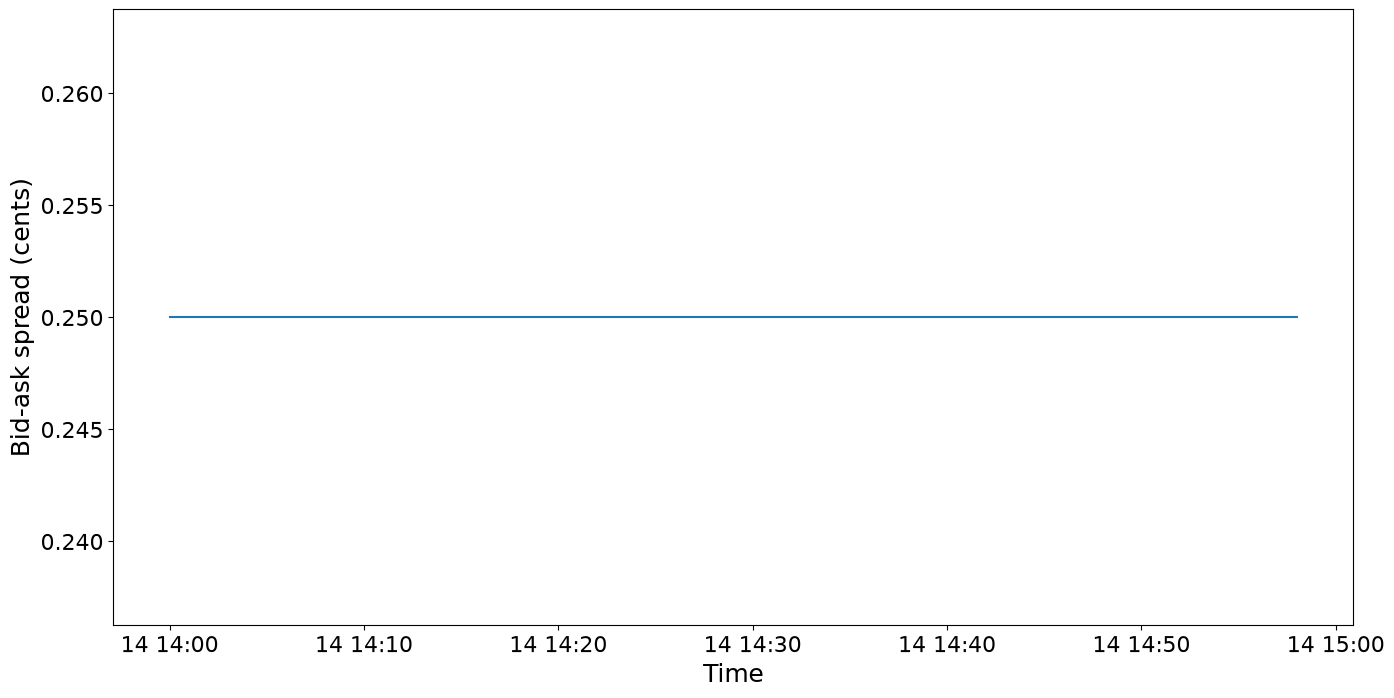

In [45]:
mbp_rs['spread_cents']=(mbp_rs['ask_px_00']-mbp_rs['bid_px_00'])
gs=gridspec.GridSpec(1,1)
fig=plt.figure(figsize=(16,8),facecolor='white')
plt.plot(mbp_rs['ts_event'].to_numpy(),mbp_rs['spread_cents'].to_numpy())
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

plt.ylabel('Bid-ask spread (cents)', fontsize=18)
plt.xlabel("Time", fontsize=18) # create an x-label with given font

### Two subplots

1. Let us plot (1) spread, (2) market depth, (3) depth imbalance, and (4) price in different subplots. 
2. We use `gridspec.GridSpec(C,R)`where C=columns, R=rows. 

(array([19614.58333333, 19614.59027778, 19614.59722222, 19614.60416667,
        19614.61111111, 19614.61805556, 19614.625     ]),
 [Text(19614.583333333332, 0, '14:00'),
  Text(19614.590277777777, 0, '14:10'),
  Text(19614.597222222223, 0, '14:20'),
  Text(19614.604166666668, 0, '14:30'),
  Text(19614.61111111111, 0, '14:40'),
  Text(19614.618055555555, 0, '14:50'),
  Text(19614.625, 0, '15:00')])

<Figure size 640x480 with 0 Axes>

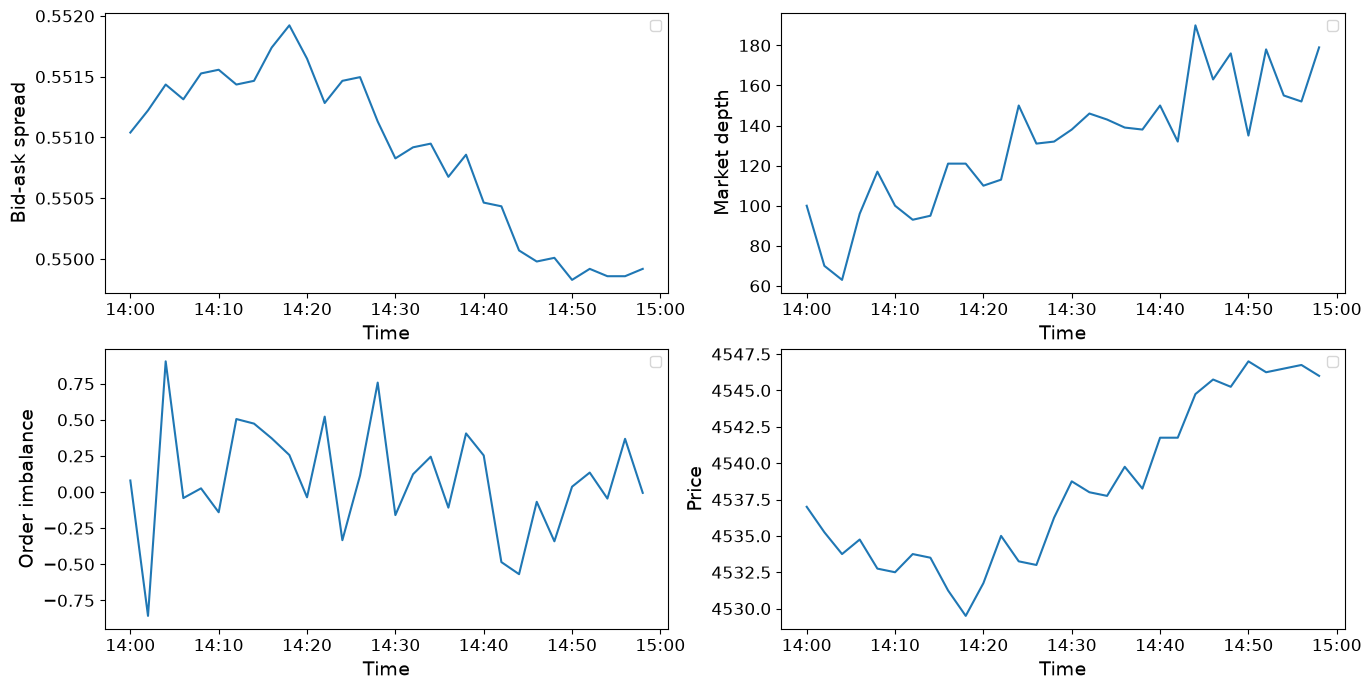

In [46]:
# Two subplots
plt.clf()

gs=gridspec.GridSpec(2,2)
fig=plt.figure(figsize=(16,8),facecolor='white') # generate a figure of given size

ax=fig.add_subplot(gs[0,0])

plt.plot(mbp_rs['ts_event'].to_numpy(),mbp_rs['spread'].to_numpy())

plt.xlabel('Time', fontsize=14)
plt.ylabel('Bid-ask spread', fontsize=14)
plt.legend(loc='best')

date_form = DateFormatter("%H:%M")
ax.xaxis.set_major_formatter(date_form)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)


ax=fig.add_subplot(gs[0,1])

mbp_rs['depth']=mbp_rs['bid_sz_00']+mbp_rs['ask_sz_00']

plt.plot(mbp_rs['ts_event'].to_numpy(),mbp_rs['depth'].to_numpy())

plt.xlabel('Time', fontsize=14)
plt.ylabel('Market depth', fontsize=14)
plt.legend(loc='best')

date_form = DateFormatter("%H:%M")
ax.xaxis.set_major_formatter(date_form)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)


ax=fig.add_subplot(gs[1,0])

mbp_rs['order_imbalance']=(mbp_rs['bid_sz_00']-mbp_rs['ask_sz_00'])/(mbp_rs['bid_sz_00']+mbp_rs['ask_sz_00'])

plt.plot(mbp_rs['ts_event'].to_numpy(),mbp_rs['order_imbalance'].to_numpy())

plt.xlabel('Time', fontsize=14)
plt.ylabel('Order imbalance', fontsize=14)
plt.legend(loc='best')

date_form = DateFormatter("%H:%M")
ax.xaxis.set_major_formatter(date_form)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)


ax=fig.add_subplot(gs[1,1])


plt.plot(mbp_rs['ts_event'].to_numpy(),mbp_rs['price'].to_numpy())

plt.xlabel('Time', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend(loc='best')

date_form = DateFormatter("%H:%M")
ax.xaxis.set_major_formatter(date_form)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)

### Histogram

1. Histograms in `seaborn` are generated by the function `sns.histplot`.
2.  The fineness of the grid can be fine-tuned through the option `bins=`.

<Axes: xlabel='size', ylabel='Probability'>

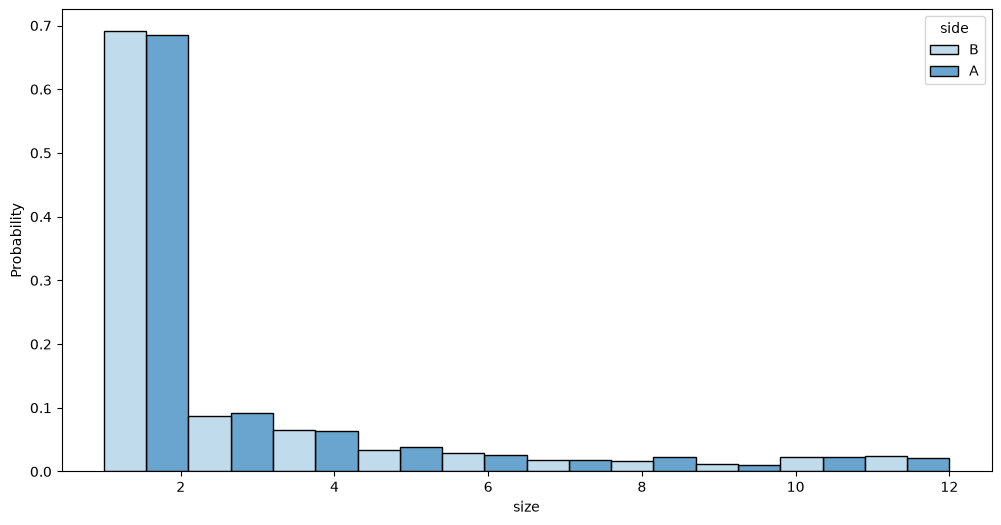

In [47]:
plt.figure(figsize=(12,6),facecolor='white')
sns.histplot(data=mbp[(mbp.action=='T') & (mbp['size']<=mbp['size'].quantile(0.99))], 
             x='size', hue='side', bins=10, multiple='dodge', stat='probability', common_norm=False,palette='Blues')

<Axes: xlabel='action', ylabel='size'>

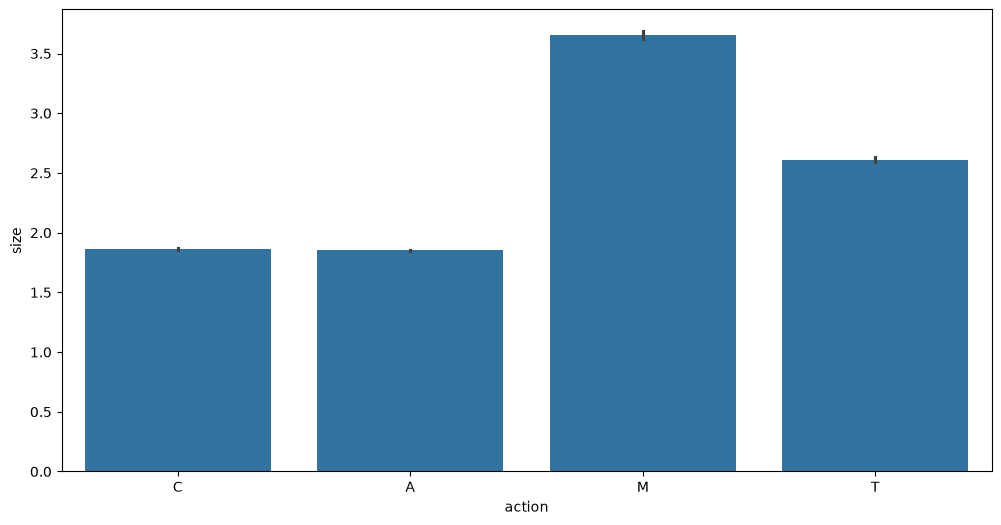

In [48]:
plt.figure(figsize=(12,6),facecolor='white')
sns.barplot(data=mbp[mbp['size']<=mbp['size'].quantile(0.99)], y='size', x='action')

### Scatterplot / Regression

We will use `seaborn.regplot` to plot a scatter of the data and fit a linear regression between market depth and absolute order imbalance.

Text(0, 0.5, 'Market depth')

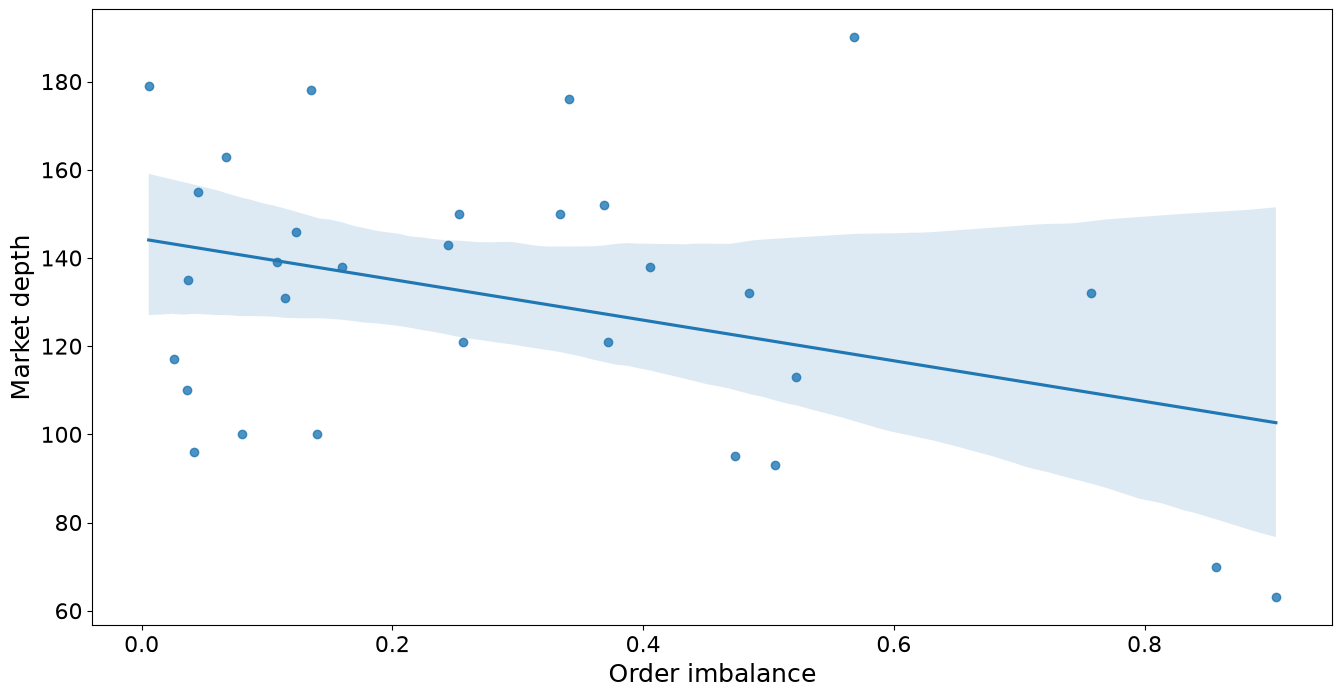

In [49]:
plt.figure(figsize=(16,8))
mbp_rs['abs_oi']=mbp_rs['order_imbalance'].map(abs)
sns.regplot(data=mbp_rs,x='abs_oi',y='depth')
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.xlabel('Order imbalance',fontsize=18)
plt.ylabel('Market depth',fontsize=18)